In [1]:
from data_preparation import DataPreparation
from loader.dataset_factory import DatasetFactory
from model.gagnn import GAGNN
from model.loss import GAGNNLoss
from sklearn.metrics import f1_score
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from utils import Evaluator
import itertools
import json
import numpy as np
import os
import pandas as pd
import torch

c:\Users\samue\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)


In [3]:
# =============================================================================
# Hyperparameters
# =============================================================================

# Model Architecture Lists for Grid Search
hidden_dims_GAT  = [64, 128]       # 64 Hidden dimension for GAT layers (as per paper)
out_dims         = [64, 128, 256]       # Output dimension of community-centric encoder 
heads_list       = [3, 5, 7, 9]        # Number of GAT attention heads (k=5 as per paper)
betas            = [0.44]     # eMRF trade-off parameter (as per paper)
mlp_hidden_dims  = [64, 128, 256]       # Hidden dimension for the edge classification MLP
nn_t_hidden_dims = [128, 256]      # 128 per paper Hidden dimension for node classification MLP (as per paper)

# tryed 32, 64 and even with the small dataset it choosed 128

# Loss weights
c1_list         = [0.75] # Group loss weight
c2_list         = [0.75] # Node loss weight
c3_list         = [1] # Transaction loss weight
laundry_weights = [1.0]  # Weight for the Laundry class loss

# [0.25, 0.5, 0.75, 1, 1.25]

# Training & CV
learning_rates  = [0.0005]    # Adam optimizer learning rate
max_norm_clipping = [5.0]
epochs_model_selection = 700        # Epochs for Cross Validation
epochs_train    =   1000         # Maximum number of training epochs
minibatches     = True       # Train with minibatches
batch_size      = 512        # Increased from 128 to stabilize gradients
num_neighbors   = [10, 10]    # max number of neighbours sampled for each node in the batch, set to -1 -1 to have no limits
patience_selection = 100 # patience during model selection
patience_training = 200 # patience during training
print_every = 2
save_every = 10

# Class Imbalance
downsample      = True     # Down-sample majority class (legitimate nodes) in training set

# Split dataset
# trainset  
date_time_1 = '2022-09-07 14:55:00'
# validation set
date_time_2 = '2022-09-08 16:12:00'
# test set


import IBM AMLSim

In [4]:
from loader.dataset_factory import DatasetFactory

# Inizializza il loader specificando il nome canonico del dataset
loader = DatasetFactory.get_loader(
    "ibm_amlsim", 
    engine="pyarrow", 
    dtype_backend="pyarrow", 
    nrows=None
)
# pyarrow is faster and uses less memory, it takes NumPy place

# Carica i dati in memoria (file delle transazioni e, se presente, degli account)
loader.load()

# Stampa un riepilogo conciso del dataset caricato per verificare che sia tutto ok
loader.summary()

Loading IBM AMLSim transactions from: c:\Users\samue\OneDrive\Desktop\tesi martino\loader\..\data\ibm_amlsim\HI-Small_Trans.csv
  Loaded 5,078,345 rows.
Loading IBM AMLSim accounts from: c:\Users\samue\OneDrive\Desktop\tesi martino\loader\..\data\ibm_amlsim\HI-Small_accounts.csv
  Loaded 518,581 account records.
  Dataset : IBMAMLSimLoader
  Rows    : 5,078,345
  Columns : 11
  Fraud   : 5,177  (0.1019 %)



In [5]:
loader.print_features()


Column               Type         Description
--------------------------------------------------------------------------------
Timestamp            string[pyarrow] Date and time of the transaction
From Bank            int64[pyarrow] Numeric identifier of the originating bank  (e.g. [1, 10, 12, 3208, 3209])
Account              string[pyarrow] Hexadecimal ID of the sender account (node)
To Bank              int64[pyarrow] Numeric identifier of the receiving bank  (e.g. [1, 10, 12, 2439, 3209])
Account.1            string[pyarrow] Hexadecimal ID of the receiver account (node)
Amount Received      double[pyarrow] Transaction amount in the receiving currency
Receiving Currency   string[pyarrow] Currency received by the destination account  (e.g. ['US Dollar', 'Bitcoin', 'Euro', 'Australian Dollar', 'Yuan', 'Rupee'])
Amount Paid          double[pyarrow] Transaction amount in the paying currency
Payment Currency     string[pyarrow] Currency used by the sender  (e.g. ['US Dollar', 'Bitcoin',

Data preparation

In [6]:
from data_preparation import DataPreparation
import pandas as pd

# Otteniamo il dataframe raw delle transazioni dal nostro loader
transactions_df = loader.get_transactions()

# Calcoliamo la maschera di training per evitare data leakage nello scaler
ts_raw = pd.to_datetime(transactions_df['Timestamp'])
thresh_val = pd.to_datetime(date_time_1)
train_mask_raw = ts_raw < thresh_val

# Inizializziamo la classe scegliendo il robust scaler
data_prep = DataPreparation(scaler_type='robust')

# 1. Calcoliamo le feature standardizzate per le transazioni (gli archi E)
edges_features_df = data_prep.fit_transform_edges(transactions_df, train_mask=train_mask_raw)

# 2. Aggreghiamo le transazioni per ricavare l'embedding iniziale dei nodi (V)
nodes_features_df = data_prep.get_node_features(edges_features_df, train_mask=train_mask_raw)

print(f"Dimensione feature archi: {edges_features_df.shape}")
print(f"Dimensione feature nodi: {nodes_features_df.shape}")

# Stampa bilanciamento classi (Nodi e Archi)
print("\n--- Bilanciamento Dataset ---")
num_fraud_nodes = (nodes_features_df["Is Laundering"] > 0).sum()
num_legit_nodes = len(nodes_features_df) - num_fraud_nodes
print(f"Nodi fraudolenti: {num_fraud_nodes} ({num_fraud_nodes/len(nodes_features_df)*100:.2f}%)")
print(f"Nodi leciti:      {num_legit_nodes} ({num_legit_nodes/len(nodes_features_df)*100:.2f}%)")

num_fraud_edges = (edges_features_df["Is Laundering"] > 0).sum()
num_legit_edges = len(edges_features_df) - num_fraud_edges
print(f"Archi fraudolenti: {num_fraud_edges} ({num_fraud_edges/len(edges_features_df)*100:.2f}%)")
print(f"Archi leciti:      {num_legit_edges} ({num_legit_edges/len(edges_features_df)*100:.2f}%)")

print("\n--- Features degli archi ---")
print(list(edges_features_df.columns))

print("\n--- Features dei nodi ---")
print(list(nodes_features_df.columns))


Extracting time features (Unix time, Cyclic Hour, Day of Week, Week)...
Applying edge transformation (Amounts: robust, Time: standard)...
Aggregating node features and extracting ground truth labels...
Dimensione feature archi: (5078345, 53)
Dimensione feature nodi: (515080, 50)

--- Bilanciamento Dataset ---
Nodi fraudolenti: 6357 (1.23%)
Nodi leciti:      508723 (98.77%)
Archi fraudolenti: 5177 (0.10%)
Archi leciti:      5073168 (99.90%)

--- Features degli archi ---
['Amount Received', 'Amount Paid', 'Receiving Currency_Australian Dollar', 'Receiving Currency_Bitcoin', 'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar', 'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso', 'Receiving Currency_Ruble', 'Receiving Currency_Rupee', 'Receiving Currency_Saudi Riyal', 'Receiving Currency_Shekel', 'Receiving Currency_Swiss Franc', 'Receiving Currency_UK Pound', 'Receiving Currency_US Dollar', 'Receiving Currency_Yen', 'Receiving Currency_Yuan', 'Payment Currency_

In [7]:
import torch
import numpy as np
import pandas as pd

print("--- Downsampling Strategy (1:1 Ratio) ---")
# 1. Identify Fraudulent and Legitimate Nodes
# A node is fraudulent if it was involved in at least one ML transaction
fraud_nodes = nodes_features_df[nodes_features_df["Is Laundering"] > 0].index
legit_nodes = nodes_features_df[nodes_features_df["Is Laundering"] == 0].index

print(f"Total Fraudulent Nodes: {len(fraud_nodes)}")
print(f"Total Legitimate Nodes (before sampling): {len(legit_nodes)}")

# 2. Sample Legitimate Nodes (1:1 ratio)
sampled_legit_nodes = pd.Series(legit_nodes).sample(n=len(fraud_nodes), random_state=42).values

# 3. Combine to form the final set of sampled users
sampled_users = set(fraud_nodes).union(set(sampled_legit_nodes))
print(f"Total Nodes after downsampling: {len(sampled_users)}")

# 4. Filter nodes_features_df and edges_features_df efficiently
nodes_features_df = nodes_features_df.loc[list(sampled_users)]

# Filter transactions: keep only those where BOTH sender and receiver are in sampled_users
edges_features_df = edges_features_df[
    edges_features_df['Account'].isin(sampled_users) & 
    edges_features_df['Account.1'].isin(sampled_users)
]

print(f"Total Edges after downsampling: {len(edges_features_df)}")

# 5. Map string Account IDs to integers (0 to N-1) for PyTorch Geometric
unique_nodes = nodes_features_df.index.unique()
node_mapping = pd.Series(index=unique_nodes, data=np.arange(len(unique_nodes)))

# 6. Extract edge_index
src = edges_features_df['Account'].map(node_mapping).values
dst = edges_features_df['Account.1'].map(node_mapping).values
edge_index = torch.tensor(np.vstack((src, dst)), dtype=torch.long)

# 7. Extract edge features and transaction labels
edge_features_cols = [c for c in edges_features_df.columns if c not in ['Account', 'Account.1', 'Is Laundering', 'Timestamp']]
edge_attr = torch.tensor(edges_features_df[edge_features_cols].values, dtype=torch.float)
y_trans = torch.tensor(edges_features_df['Is Laundering'].values, dtype=torch.float).unsqueeze(1)

# 8. Extract node features and node labels
node_features_cols = [c for c in nodes_features_df.columns if c != 'Is Laundering']
x = torch.tensor(nodes_features_df[node_features_cols].values, dtype=torch.float)

y_node = torch.tensor(nodes_features_df['Is Laundering'].values, dtype=torch.float)

print(f"Node features shape: {x.shape}")
print(f"Edge index shape: {edge_index.shape}")
print(f"Edge features shape: {edge_attr.shape}")


--- Downsampling Strategy (1:1 Ratio) ---
Total Fraudulent Nodes: 6357
Total Legitimate Nodes (before sampling): 508723
Total Nodes after downsampling: 12714
Total Edges after downsampling: 52250
Node features shape: torch.Size([12714, 49])
Edge index shape: torch.Size([2, 52250])
Edge features shape: torch.Size([52250, 49])


In [8]:
import pandas as pd
from torch_geometric.data import Data

# Convert Timestamp column to datetime (use downsampled edges_features_df)
ts = pd.to_datetime(edges_features_df['Timestamp'])

# Thresholds for splits
thresh_val = pd.to_datetime(date_time_1)
thresh_test = pd.to_datetime(date_time_2)

# Create edge masks based on chronological splits
train_edge_mask = torch.tensor((ts < thresh_val).values, dtype=torch.bool)
val_edge_mask = torch.tensor(((ts >= thresh_val) & (ts < thresh_test)).values, dtype=torch.bool)
test_edge_mask = torch.tensor((ts >= thresh_test).values, dtype=torch.bool)

print(f"Train edges: {train_edge_mask.sum().item()} ({train_edge_mask.sum().item()/len(ts)*100:.1f}%)")
print(f"Val edges: {val_edge_mask.sum().item()} ({val_edge_mask.sum().item()/len(ts)*100:.1f}%)")
print(f"Test edges: {test_edge_mask.sum().item()} ({test_edge_mask.sum().item()/len(ts)*100:.1f}%)")

# Create node masks for NeighborLoader input_nodes
# A node is in the training set if it is connected to at least one training edge
train_nodes_idx = edge_index[:, train_edge_mask].flatten().unique()
train_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
train_node_mask[train_nodes_idx] = True

val_nodes_idx = edge_index[:, val_edge_mask].flatten().unique()
val_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
val_node_mask[val_nodes_idx] = True

test_nodes_idx = edge_index[:, test_edge_mask].flatten().unique()
test_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
test_node_mask[test_nodes_idx] = True

# Node mask: Using all True, as GAGNN expects a probability label for all nodes
node_mask = torch.ones(x.shape[0], dtype=torch.bool)

# Build PyG Data object
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y_trans=y_trans, y_node=y_node)
data.node_mask = node_mask
data.edge_train_mask = train_edge_mask
data.edge_val_mask = val_edge_mask
data.edge_test_mask = test_edge_mask
data.train_node_mask = train_node_mask
data.val_node_mask = val_node_mask
data.test_node_mask = test_node_mask


Train edges: 38238 (73.2%)
Val edges: 4535 (8.7%)
Test edges: 9477 (18.1%)


### Model selection

Batches per epoch (Train): 22 | (Val): 5
Total hyperparameter combinations: 144

--- Experiment 1/144 ---
{'max_norm': 5.0, 'hidden_dim_GAT': 64, 'out_dim': 64, 'heads': 3, 'beta': 0.44, 'mlp_hidden_dim': 64, 'nn_t_hidden_dim': 128, 'lr': 0.0005, 'c1': 0.75, 'c2': 0.75, 'c3': 1, 'laundry_weight': 1.0}
Epoch 002 | Train Loss: 313.0016 | Val F1-score: 0.0650
Epoch 004 | Train Loss: 57.0339 | Val F1-score: 0.0474
Epoch 006 | Train Loss: 40.0405 | Val F1-score: 0.1004
Epoch 008 | Train Loss: 14.4333 | Val F1-score: 0.1220
Epoch 010 | Train Loss: 19.3192 | Val F1-score: 0.3262
Epoch 012 | Train Loss: 8.6072 | Val F1-score: 0.3101
Epoch 014 | Train Loss: 22.0585 | Val F1-score: 0.3303
Epoch 016 | Train Loss: 14.6480 | Val F1-score: 0.2325
Epoch 018 | Train Loss: 7.9894 | Val F1-score: 0.0325
Epoch 020 | Train Loss: 6.3773 | Val F1-score: 0.1996
Epoch 022 | Train Loss: 9.7842 | Val F1-score: 0.0753
Epoch 024 | Train Loss: 3.1038 | Val F1-score: 0.0783
Epoch 026 | Train Loss: 4.0507 | Val F1-s

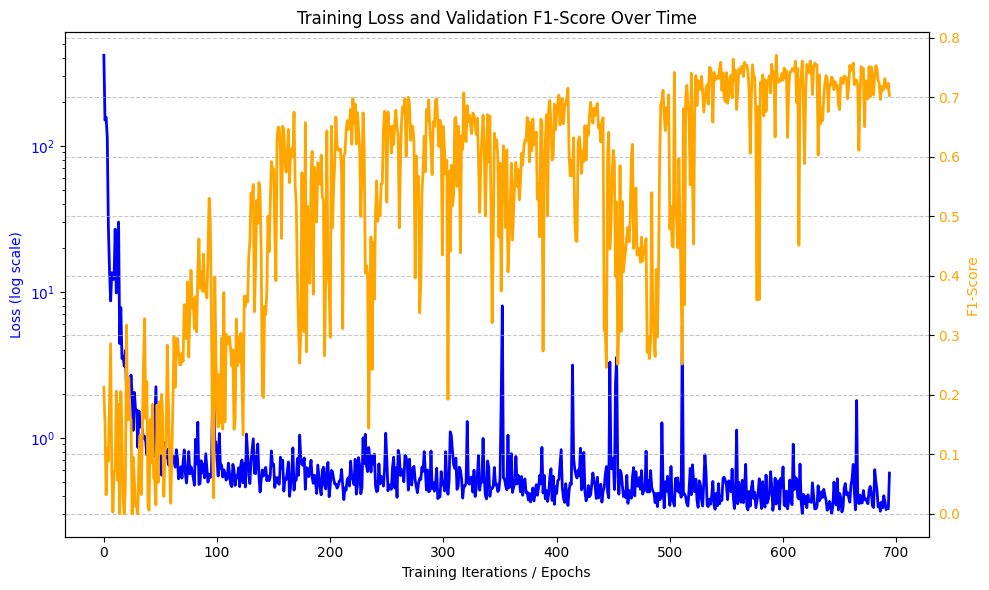

In [9]:
import os
import json
import itertools
from model.gagnn import GAGNN
from model.loss import GAGNNLoss
from torch_geometric.loader import NeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if minibatches:
    train_loader = NeighborLoader(
        data, num_neighbors=num_neighbors, batch_size=batch_size,
        input_nodes=data.train_node_mask, shuffle=True
    )
    
    val_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.val_node_mask, shuffle=False
    )
else:
    d_dev = data.to(device)
    train_loader = [d_dev]
    val_loader = [d_dev]

print(f"Batches per epoch (Train): {len(train_loader)} | (Val): {len(val_loader)}")

keys = ['max_norm', 'hidden_dim_GAT', 'out_dim', 'heads', 'beta', 'mlp_hidden_dim', 'nn_t_hidden_dim', 'lr', 'c1', 'c2', 'c3', 'laundry_weight']
combinations = list(itertools.product(
    max_norm_clipping, hidden_dims_GAT, out_dims, heads_list, betas, mlp_hidden_dims, nn_t_hidden_dims, learning_rates, c1_list, c2_list, c3_list, laundry_weights
))

print(f"Total hyperparameter combinations: {len(combinations)}\n")

from sklearn.metrics import f1_score
import numpy as np
best_val_f1 = -1.0
best_params = None

os.makedirs("saved_models", exist_ok=True)

for idx, combo in enumerate(combinations):
    params = dict(zip(keys, combo))
    print(f"--- Experiment {idx+1}/{len(combinations)} ---")
    print(params)
    
    model = GAGNN(
        node_in_dim=x.shape[1],
        edge_feat_dim=edge_attr.shape[1],
        hidden_dim=params['hidden_dim_GAT'],
        out_dim=params['out_dim'],
        heads=params['heads'],
        beta=params['beta'],
        mlp_hidden_dim=params['mlp_hidden_dim'],
        nn_t_hidden_dim=params['nn_t_hidden_dim'],
        minibatches=minibatches
    ).to(device)
    
    criterion = GAGNNLoss(c1=params['c1'], c2=params['c2'], c3=params['c3'], laundry_weight=params['laundry_weight'])
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    
    epochs_no_improve = 0
    best_model_val_f1 = -1.0
    
    for epoch in range(epochs_model_selection):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            p_node, p_trans, p_group, y_group = model(
                batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_train_mask
            )
            
            if p_group.numel() > 0:
                loss, _, _, _ = criterion(
                    p_node, batch.y_node.view(-1, 1),
                    p_trans, batch.y_trans,
                    p_group, y_group,
                    node_mask=batch.node_mask,
                    trans_mask=batch.edge_train_mask
                )
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=params['max_norm'])
                optimizer.step()
                epoch_loss += loss.item()
                n_batches += 1
                
        train_loss = epoch_loss / max(n_batches, 1)
        model.training_losses.append(train_loss)
        
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                p_node, p_trans, p_group, y_group = model(
                    batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                    y_trans=batch.y_trans, trans_mask=batch.edge_val_mask
                )
                if p_group.numel() > 0:
                    p_trans_val = p_trans[batch.edge_val_mask]
                    y_trans_val = batch.y_trans[batch.edge_val_mask]
                    probs = torch.sigmoid(p_trans_val)
                    probs_flat = probs.view(-1).cpu().numpy()
                    preds = (probs_flat >= 0.5).astype(int)
                    labels = y_trans_val.view(-1).long().cpu().numpy()
                    all_preds.append(preds)
                    all_labels.append(labels)
                    
        if len(all_preds) > 0:
            all_preds = np.concatenate(all_preds)
            all_labels = np.concatenate(all_labels)
            val_f1 = f1_score(all_labels, all_preds, zero_division=0)
        else:
            val_f1 = 0.0

        model.val_F1.append(val_f1)
        if val_f1 > best_model_val_f1:
            best_model_val_f1 = val_f1
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience_selection:
            print(f"Patience triggered at epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val F1-score: {val_f1:.4f}")
            break
            
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val F1-score: {val_f1:.4f}")   
        
            
    print(f"Best Val F1-score for this config: {best_model_val_f1:.4f}")
    if best_model_val_f1 > best_val_f1:
        best_val_f1 = best_model_val_f1
        best_params = params
        model.save("saved_models/gagnn_best_model_selection.pt")
        print(">>> New Best Parameters! Model saved.")
    else:
        print(f"No improvement over best parameters. Current: {best_model_val_f1:.4f} | Best: {best_val_f1:.4f}")

print("\n=========================================")
print(f"Overall Best Val F1-score: {best_val_f1:.4f}")
print(f"Best Parameters: {best_params}")
print("=========================================")
with open("saved_models/best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

print("\nPlotting training history of the best model from model selection...")
best_selection_model = GAGNN.load_saved("saved_models/gagnn_best_model_selection.pt")
best_selection_model.plot_training_history()


### Training


Loading best hyperparameters for final training...

Starting final training on Train dataset with validation...
Batches per epoch (Final Train): 22
Train Epoch 002/1000 | Train Loss: 146.3043 | Val F1: 0.2109
Train Epoch 004/1000 | Train Loss: 86.0371 | Val F1: 0.0149
Train Epoch 006/1000 | Train Loss: 22.9921 | Val F1: 0.0439
Train Epoch 008/1000 | Train Loss: 24.5545 | Val F1: 0.2043
Train Epoch 010/1000 | Train Loss: 59.0335 | Val F1: 0.0863
Train Epoch 012/1000 | Train Loss: 12.3214 | Val F1: 0.2178
Train Epoch 014/1000 | Train Loss: 7.4195 | Val F1: 0.1504
Train Epoch 016/1000 | Train Loss: 3.0021 | Val F1: 0.0000
Train Epoch 018/1000 | Train Loss: 1.6741 | Val F1: 0.2544
Train Epoch 020/1000 | Train Loss: 2.9773 | Val F1: 0.0885
Train Epoch 022/1000 | Train Loss: 1.3753 | Val F1: 0.0509
Train Epoch 024/1000 | Train Loss: 0.8337 | Val F1: 0.0961
Train Epoch 026/1000 | Train Loss: 1.8802 | Val F1: 0.0326
Train Epoch 028/1000 | Train Loss: 0.8637 | Val F1: 0.0237
Train Epoch 030/10

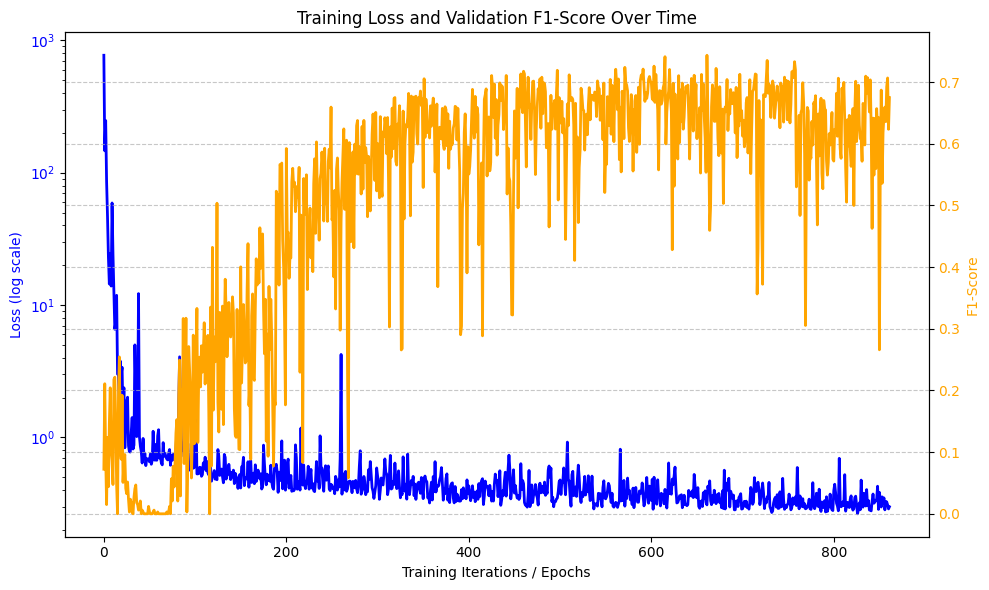

In [10]:
import os
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best hyperparameters for final training...")
with open("saved_models/best_params.json", "r") as f:
    best_params = json.load(f)

print("\nStarting final training on Train dataset with validation...")

if minibatches:
    final_train_loader = NeighborLoader(
        data, num_neighbors=num_neighbors, batch_size=batch_size,
        input_nodes=data.train_node_mask, shuffle=True
    )
    final_val_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.val_node_mask, shuffle=False
    )
else:
    final_train_loader = [d_dev]
    final_val_loader = [d_dev]

print(f"Batches per epoch (Final Train): {len(final_train_loader)}")

# Re-initialize the model with best parameters
final_model = GAGNN(
    node_in_dim=x.shape[1],
    edge_feat_dim=edge_attr.shape[1],
    hidden_dim=best_params['hidden_dim_GAT'],
    out_dim=best_params['out_dim'],
    heads=best_params['heads'],
    beta=best_params['beta'],
    mlp_hidden_dim=best_params['mlp_hidden_dim'],
    nn_t_hidden_dim=best_params['nn_t_hidden_dim'],
    minibatches=minibatches
).to(device)

final_criterion = GAGNNLoss(c1=best_params['c1'], c2=best_params['c2'], c3=best_params['c3'], laundry_weight=best_params.get('laundry_weight', 2.0))
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])

os.makedirs("saved_models", exist_ok=True)

best_final_val_f1 = -1.0
epochs_no_improve = 0

for epoch in range(epochs_train):
    final_model.train()
    epoch_loss = 0.0
    n_batches = 0
    
    for batch in final_train_loader:
        batch = batch.to(device)
        final_optimizer.zero_grad()
        
        p_node, p_trans, p_group, y_group = final_model(
            batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
            y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_train_mask
        )
        
        if p_group.numel() > 0:
            loss, _, _, _ = final_criterion(
                p_node, batch.y_node.view(-1, 1),
                p_trans, batch.y_trans,
                p_group, y_group,
                node_mask=batch.node_mask,
                trans_mask=batch.edge_train_mask
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=best_params['max_norm'])
            final_optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
            
    train_loss = epoch_loss / max(n_batches, 1)
    final_model.training_losses.append(train_loss)
    
    # Validation step
    final_model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in final_val_loader:
            batch = batch.to(device)
            p_node, p_trans, p_group, y_group = final_model(
                batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                y_trans=batch.y_trans, trans_mask=batch.edge_val_mask
            )
            if p_group.numel() > 0:
                p_trans_val = p_trans[batch.edge_val_mask]
                y_trans_val = batch.y_trans[batch.edge_val_mask]
                probs = torch.sigmoid(p_trans_val)
                probs_flat = probs.view(-1).cpu().numpy()
                preds = (probs_flat >= 0.5).astype(int)
                labels = y_trans_val.view(-1).long().cpu().numpy()
                all_preds.append(preds)
                all_labels.append(labels)
                
    if len(all_preds) > 0:
        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        val_f1 = f1_score(all_labels, all_preds, zero_division=0)
    else:
        val_f1 = 0.0
        
    final_model.val_F1.append(val_f1)
    
    if (epoch + 1) % print_every == 0:
        print(f"Train Epoch {epoch+1:03d}/{epochs_train} | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")
        
    if val_f1 > best_final_val_f1:
        best_final_val_f1 = val_f1
        epochs_no_improve = 0
        final_model.save("saved_models/model_trained_final.pt")
        # print(">>> Saved new best model checkpoint.")
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience_training:
        print(f"Patience triggered at epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val F1-score: {val_f1:.4f}")
        break
        
    # Save model every 10 epochs
    if (epoch + 1) % save_every == 0:
        final_model.save(f"saved_models/model_trained_{epoch+1}.pt")
        # print(f"  -> Saved model checkpoint to saved_models/model_trained_{epoch+1}.pt")

print("\nPlotting training history of the final trained model...")
final_model.plot_training_history()



Loading best model for final evaluation on Test set...
    EVALUATION REPORT (Transactions / Edges)
  Accuracy  : 0.9235
  Precision : 0.8006
  Recall    : 0.7948
  F1-Score  : 0.7977
  ROC-AUC   : 0.9222
--------------------------------------------------
              precision    recall  f1-score   support

       Legit       0.95      0.95      0.95      7679
  Laundering       0.80      0.79      0.80      1798

    accuracy                           0.92      9477
   macro avg       0.88      0.87      0.88      9477
weighted avg       0.92      0.92      0.92      9477



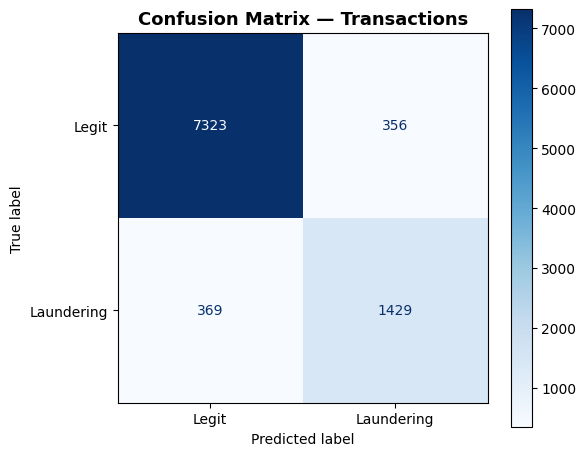

In [ ]:
from utils import Evaluator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best model for final evaluation on Test set...")
eval_model = GAGNN.load_saved("saved_models/model_trained_final.pt").to(device)

with open("saved_models/best_params.json", "r") as f:
    best_params = json.load(f)

eval_criterion = GAGNNLoss(c1=best_params['c1'], c2=best_params['c2'], c3=best_params['c3'])

if minibatches:
    test_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.test_node_mask, shuffle=False
    )
    Evaluator.evaluation_report(eval_model, test_loader, eval_criterion, device, edge_mask_name='edge_test_mask')
else:
    Evaluator.evaluation_report(eval_model, [d_dev], eval_criterion, device, edge_mask_name='edge_test_mask')


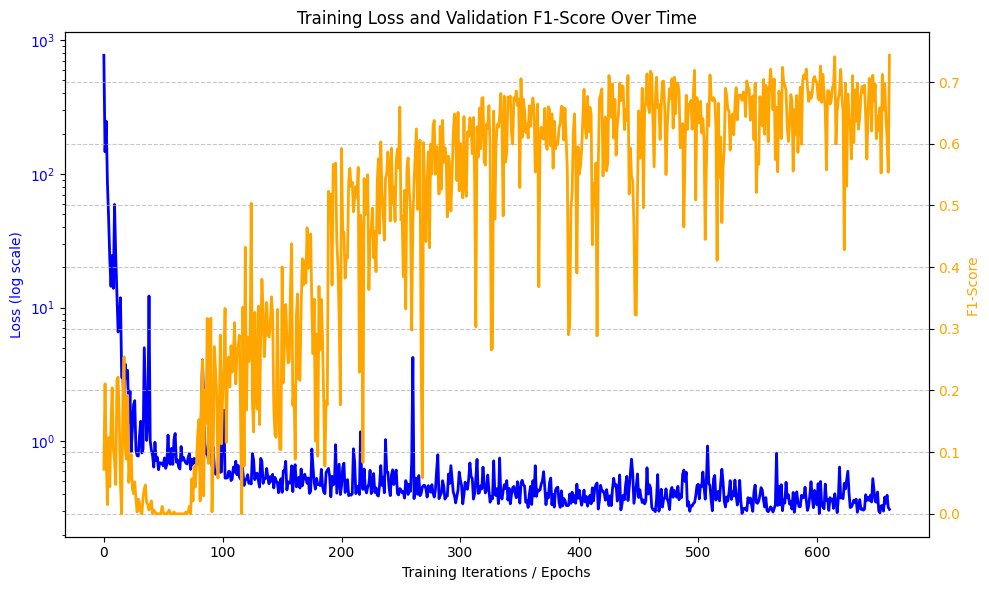

In [13]:
eval_model.plot_training_history()

model with double weight for laundering


Loading best hyperparameters for final training...

Starting final training on Train dataset with validation...
Batches per epoch (Final Train): 22
Train Epoch 002/1000 | Train Loss: 206.8164 | Val F1: 0.0232
Train Epoch 004/1000 | Train Loss: 56.4481 | Val F1: 0.1624
Train Epoch 006/1000 | Train Loss: 36.1251 | Val F1: 0.1122
Train Epoch 008/1000 | Train Loss: 29.8964 | Val F1: 0.1763
Train Epoch 010/1000 | Train Loss: 21.2539 | Val F1: 0.0608
Train Epoch 012/1000 | Train Loss: 16.8038 | Val F1: 0.1982
Train Epoch 014/1000 | Train Loss: 18.5897 | Val F1: 0.1191
Train Epoch 016/1000 | Train Loss: 16.9902 | Val F1: 0.1502
Train Epoch 018/1000 | Train Loss: 5.4854 | Val F1: 0.2000
Train Epoch 020/1000 | Train Loss: 3.0970 | Val F1: 0.0931
Train Epoch 022/1000 | Train Loss: 5.0146 | Val F1: 0.0749
Train Epoch 024/1000 | Train Loss: 3.4857 | Val F1: 0.0316
Train Epoch 026/1000 | Train Loss: 2.4546 | Val F1: 0.2217
Train Epoch 028/1000 | Train Loss: 4.5028 | Val F1: 0.1339
Train Epoch 030/

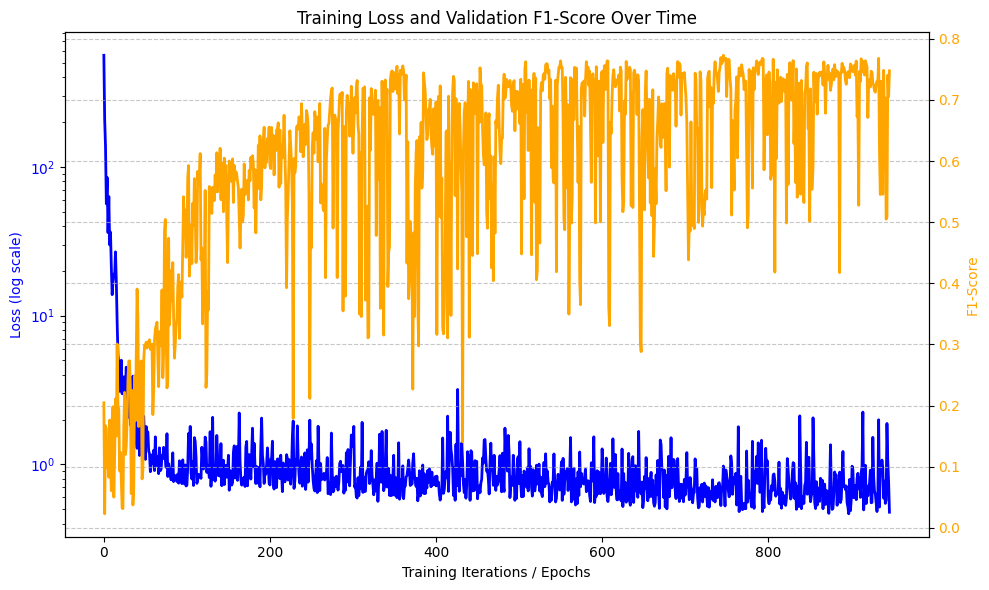

In [15]:
import os
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best hyperparameters for final training...")
with open("saved_models/best_params.json", "r") as f:
    best_params = json.load(f)

print("\nStarting final training on Train dataset with validation...")

if minibatches:
    final_train_loader = NeighborLoader(
        data, num_neighbors=num_neighbors, batch_size=batch_size,
        input_nodes=data.train_node_mask, shuffle=True
    )
    final_val_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.val_node_mask, shuffle=False
    )
else:
    final_train_loader = [d_dev]
    final_val_loader = [d_dev]

print(f"Batches per epoch (Final Train): {len(final_train_loader)}")

# Re-initialize the model with best parameters
final_model = GAGNN(
    node_in_dim=x.shape[1],
    edge_feat_dim=edge_attr.shape[1],
    hidden_dim=best_params['hidden_dim_GAT'],
    out_dim=best_params['out_dim'],
    heads=best_params['heads'],
    beta=best_params['beta'],
    mlp_hidden_dim=best_params['mlp_hidden_dim'],
    nn_t_hidden_dim=best_params['nn_t_hidden_dim'],
    minibatches=minibatches
).to(device)

final_criterion = GAGNNLoss(c1=best_params['c1'], c2=best_params['c2'], c3=best_params['c3'], laundry_weight=2.0)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])

os.makedirs("saved_models", exist_ok=True)

best_final_val_f1 = -1.0
epochs_no_improve = 0

for epoch in range(epochs_train):
    final_model.train()
    epoch_loss = 0.0
    n_batches = 0
    
    for batch in final_train_loader:
        batch = batch.to(device)
        final_optimizer.zero_grad()
        
        p_node, p_trans, p_group, y_group = final_model(
            batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
            y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_train_mask
        )
        
        if p_group.numel() > 0:
            loss, _, _, _ = final_criterion(
                p_node, batch.y_node.view(-1, 1),
                p_trans, batch.y_trans,
                p_group, y_group,
                node_mask=batch.node_mask,
                trans_mask=batch.edge_train_mask
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=best_params['max_norm'])
            final_optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
            
    train_loss = epoch_loss / max(n_batches, 1)
    final_model.training_losses.append(train_loss)
    
    # Validation step
    final_model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in final_val_loader:
            batch = batch.to(device)
            p_node, p_trans, p_group, y_group = final_model(
                batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                y_trans=batch.y_trans, trans_mask=batch.edge_val_mask
            )
            if p_group.numel() > 0:
                p_trans_val = p_trans[batch.edge_val_mask]
                y_trans_val = batch.y_trans[batch.edge_val_mask]
                probs = torch.sigmoid(p_trans_val)
                probs_flat = probs.view(-1).cpu().numpy()
                preds = (probs_flat >= 0.5).astype(int)
                labels = y_trans_val.view(-1).long().cpu().numpy()
                all_preds.append(preds)
                all_labels.append(labels)
                
    if len(all_preds) > 0:
        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        val_f1 = f1_score(all_labels, all_preds, zero_division=0)
    else:
        val_f1 = 0.0
        
    final_model.val_F1.append(val_f1)
    
    if (epoch + 1) % print_every == 0:
        print(f"Train Epoch {epoch+1:03d}/{epochs_train} | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")
        
    if val_f1 > best_final_val_f1:
        best_final_val_f1 = val_f1
        epochs_no_improve = 0
        final_model.save("saved_models/model_trained_weighted2_final.pt")
        # print(">>> Saved new best model checkpoint.")
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience_training:
        print(f"Patience triggered at epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val F1-score: {val_f1:.4f}")
        break
        
    # Save model every 10 epochs
    if (epoch + 1) % save_every == 0:
        final_model.save(f"saved_models/model_trained_weighted2_{epoch+1}.pt")
        # print(f"  -> Saved model checkpoint to saved_models/model_trained_weighted2_{epoch+1}.pt")

print("\nPlotting training history of the final trained model...")
final_model.plot_training_history()



Loading best model for final evaluation on Test set...
    EVALUATION REPORT (Transactions / Edges)
  Accuracy  : 0.9310
  Precision : 0.8082
  Recall    : 0.8343
  F1-Score  : 0.8210
  ROC-AUC   : 0.9265
--------------------------------------------------
              precision    recall  f1-score   support

       Legit       0.96      0.95      0.96      7679
  Laundering       0.81      0.83      0.82      1798

    accuracy                           0.93      9477
   macro avg       0.88      0.89      0.89      9477
weighted avg       0.93      0.93      0.93      9477



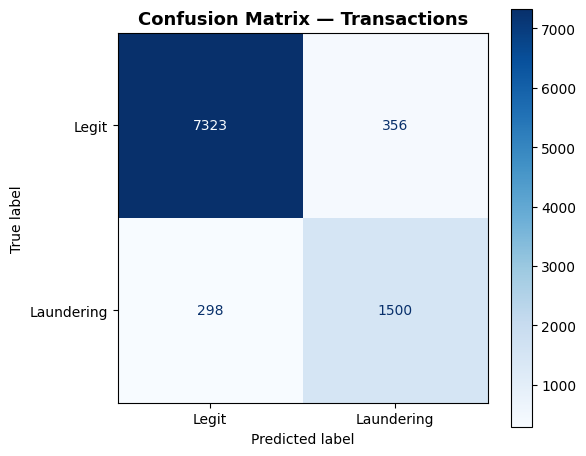

In [16]:
from utils import Evaluator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best model for final evaluation on Test set...")
eval_model = GAGNN.load_saved("saved_models/model_trained_weighted2_final.pt").to(device)

with open("saved_models/best_params.json", "r") as f:
    best_params = json.load(f)

eval_criterion = GAGNNLoss(c1=best_params['c1'], c2=best_params['c2'], c3=best_params['c3'], laundry_weight=2.0)

if minibatches:
    test_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.test_node_mask, shuffle=False
    )
    Evaluator.evaluation_report(eval_model, test_loader, eval_criterion, device, edge_mask_name='edge_test_mask')
else:
    Evaluator.evaluation_report(eval_model, [d_dev], eval_criterion, device, edge_mask_name='edge_test_mask')
